# tensorflow2.0模型训练

## 【章节目标】
- 了解tensorflow训练模型的方式
- 掌握使用keras高级api进行模型训练的方法
- 掌握使用tf.GradientTape进行自定义模型训练的方法
- 掌握模型保存和加载的方法
- 掌握使用tensorflow进行深度学习模型训练的完整流程

## 【章节内容】
### tensorflow模型训练方式

tensorflow模型训练主要方式有：

- Keras内置fit方法
- Keras内置tran_on_batch方法
- tf.GradientTape自定义训练循环

### Keras高级API
在训练网络时，一般的流程是通过前向计算获得网络的输出值，再通过损失函数计算网络误差，然后通过自动求导工具计算梯度并更新，同时间隔性地测试网络的性能。对于这种常用的训练逻辑，可以直接通过 Keras 提供的模型装配与训练高层接口实现，简洁清晰。

- 构建模型（顺序模型、函数式模型、子类模型）
- 模型配置：compile()
- 模型训练：model.fit()、model.tran_on_batch()
- 模型验证：model.evaluate()
- 模型预测：model.predict()
- 使用样本加权和类别加权

下面我们以Lenet实现手写数字识别为例来说明Keras高级api的用法。

#### 1）加载mnist数据集并创建Dataset

In [1]:
import tensorflow as tf

2026-04-06 08:57:48.378425: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-06 08:57:48.378604: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-06 08:57:48.447874: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
from tensorflow.keras import datasets # 导入经典数据集加载模块
# 加载MNIST数据集
(x, y), (x_test, y_test) = datasets.mnist.load_data()
print('x:', x.shape, 'y:', y.shape, 'x_test:', x_test.shape, "y_test:", y_test)
# 构建数据集
train_db = tf.data.Dataset.from_tensor_slices((x, y)).shuffle(10000).batch(128)
val_db = tf.data.Dataset.from_tensor_slices((x_test[:5000], y_test[:5000])).shuffle(5000).batch(256)
test_db = tf.data.Dataset.from_tensor_slices((x_test[5000:], y_test[5000:])).shuffle(5000).batch(256)

x: (60000, 28, 28) y: (60000,) x_test: (10000, 28, 28) y_test: [7 2 1 ... 4 5 6]


2026-04-06 09:01:39.499827: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.


In [3]:
def preprocess(x, y): # 自定义的预处理函数
    # 调用此函数时会自动传入 x,y 对象，shape 为[b, 28, 28], [b]
    # 标准化到 0~1
    x = tf.cast(x, dtype=tf.float32) / 255. #归一化到0-1
    x = tf.reshape(x, [-1,28,28,1]) # 增加通道维度
    y = tf.cast(y, dtype=tf.int32) # 转成整形张量 
    y = tf.one_hot(y, depth=10) # one-hot 编码
    # 返回的 x,y 将替换传入的 x,y 参数，从而实现数据的预处理功能
    return x,y

# 预处理函数实现在 preprocess 函数中，传入函数引用即可
train_db = train_db.map(preprocess).cache() #第一次迭代读取，然后缓存 后续迭代速度就快了
test_db = test_db.map(preprocess).cache() 
val_db = val_db.map(preprocess).cache() 

#### 2）构建模型
Lenet模型结构图如下：

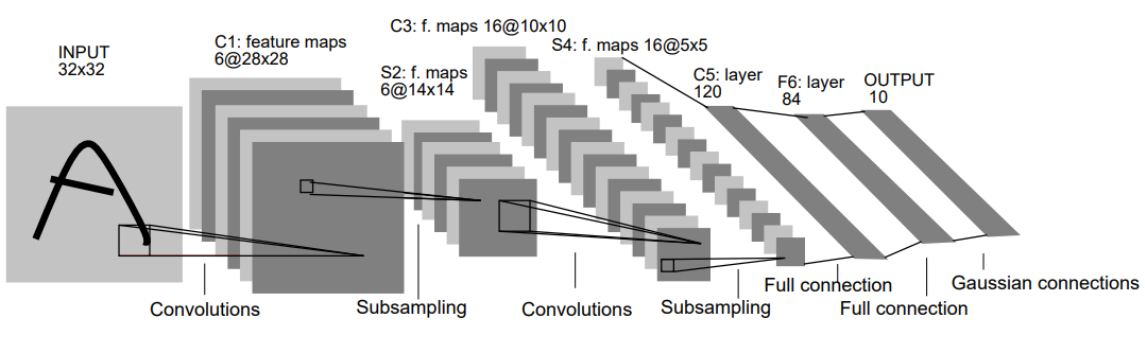

在 Keras 中，有 2 个比较特殊的类：keras.Model 和 keras.layers.Layer 类。其中 Layer 类是网络层的母类，定义了网络层的一些常见功能，如添加权值，管理权值列表等。Model 类是网络的母类，除了具有 Layer 类的功能，还添加了保存、加载模型，训练与测试模型等便捷功能。Sequential 也是 Model 的子类，因此具有 Model 类的所有功能。

使用Sequential方式搭建模型：

In [4]:
from tensorflow.keras import layers
lenet = tf.keras.models.Sequential([
    #第一层：6个5*5的卷积核，全0填充；最大池化，2*2的池化核，步长为2，padding='VALID'
    layers.Conv2D(filters=6,kernel_size=5,activation='relu',padding='same'),
    layers.MaxPool2D(pool_size=2,strides=2),
    #第二层
    layers.Conv2D(filters=16,kernel_size=5,activation='relu',padding='same'),
    layers.MaxPool2D(pool_size=2,strides=2),
    #拉直,将(28,28)像素的图像即对应的2维的数组转成一维的数组
    layers.Flatten(),
    #三层全连接网络
    #120个神经元
    layers.Dense(120,activation='relu'),
    layers.Dense(84,activation='relu'),
    layers.Dense(10,activation='softmax')#最后一层可以加softmax 输出的是prob 也可以不加 输出的是logits  加不加影响损失函数的计算
])

lenet.build(input_shape=(None, 28,28,1))#初始化模型参数
lenet.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 28, 28, 6)         156       
                                                                 
 max_pooling2d (MaxPooling2  (None, 14, 14, 6)         0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 14, 14, 16)        2416      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 7, 7, 16)          0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 120)               9

#### 3）配置：compile()
建立好模型之后，接下来当然是要进行训练模型了。不过，在训练前还需要做一些配置工作，例如指定优化器、损失函数、评估指标等，这些配置参数的过程一般通过 tf.keras.Model.compile 方法进行，先来熟悉一下 tf.keras.Model.compile 方法的三个常用参数：

- optimizer：tf.keras.optimizers 模块中的优化器实例化对象，例如 tf.keras.optimizers.Adam 或 tf.keras.optimizers.SGD 的**实例化对象**，当然也可以使用字符串来指代优化器，例如'adam'和'sgd'。

- loss：损失函数，例如交叉熵、均方差等，通常是 tf.keras.losses 模块中定义的可调用对象，也可以用用于指代损失函数的字符串。

- metrics：元素为评估方法的list，通常是定义在 tf.keras.metrics 模块中定义的可调用对象，也可以用于指代评估方法的字符串。

在知道怎么配置模型训练参数后，就可以根据实际应用情况合理选择优化器、损失函数、评估方法等：

In [6]:
#损失函数和训练算法采用交叉熵损失函数(cross entropy)和Adam
optimizer = tf.keras.optimizers.Adam(learning_rate=0.01) # 是对象！

# 编译模型
lenet.compile(optimizer = optimizer,
              loss = tf.keras.losses.CategoricalCrossentropy(),
              metrics = ['accuracy']) #评估指标可以有多个

#### 4）训练: fit()
通过compile()配置好模型后，就可以开始训练了。tf.keras中提供了fit()方法对模型进行训练，先来看看fit()方法的主要参数：

- x和y：训练数据和目标数据
- epochs：训练周期数，每一个周期都是对训练数据集的一次完整迭代
- batch_size：簇的大小，一般在数据集是numpy数组类型时使用
- validation_data：验证数据集，模型训练时，如果你想通过一个额外的验证数据集来监测模型的性能变换，就可以通过这个参数传入验证数据集
- verbose：日志显示方式，verbose=0为不在标准输出流输出日志信息,verbose=1为输出进度条记录，verbose=2为每个epoch输出一行记录
- callbacks：回调方法组成的列表，一般是定义在tf.keras.callbacks中的方法
- validation_split：从训练数据集抽取部分数据作为验证数据集的比例，是一个0到1之间的浮点数。这一参数在输入数据为dataset对象、生成器、keras.utils.Sequence对象是无效。
- shuffle：是否在每一个周期开始前打乱数据

**numpy数据训练方式**

In [7]:
import numpy as np

labels = np.eye(10) # 单位阵来实现onehot
train_x, train_y = x.reshape(-1, 28, 28, 1) / 255. - 0.5, labels[y.astype(np.int16), :] # 按标签数值去取单位矩阵的对应行
print(train_x.shape, train_y.shape)

lenet.fit(train_x, train_y, epochs=5, batch_size=128, validation_split=0.1)

(60000, 28, 28, 1) (60000, 10)
Epoch 1/5


I0000 00:00:1775469611.545574    2555 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


422/422 [==============================] - 7s 8ms/step - loss: 0.1661 - accuracy: 0.9475 - val_loss: 0.0487 - val_accuracy: 0.9862
Epoch 2/5
422/422 [==============================] - 4s 10ms/step - loss: 0.0624 - accuracy: 0.9819 - val_loss: 0.0616 - val_accuracy: 0.9828
Epoch 3/5
422/422 [==============================] - 4s 9ms/step - loss: 0.0516 - accuracy: 0.9851 - val_loss: 0.0596 - val_accuracy: 0.9848
Epoch 4/5
422/422 [==============================] - 4s 9ms/step - loss: 0.0478 - accuracy: 0.9865 - val_loss: 0.0469 - val_accuracy: 0.9882
Epoch 5/5
422/422 [==============================] - 4s 9ms/step - loss: 0.0428 - accuracy: 0.9878 - val_loss: 0.0569 - val_accuracy: 0.9858


**Dataset数据训练方式：**

In [8]:
lenet.fit(train_db, epochs=5, validation_data=val_db)

Epoch 1/5
469/469 [==============================] - 4s 9ms/step - loss: 0.0576 - accuracy: 0.9848 - val_loss: 0.0798 - val_accuracy: 0.9792
Epoch 2/5
469/469 [==============================] - 4s 8ms/step - loss: 0.0454 - accuracy: 0.9878 - val_loss: 0.1106 - val_accuracy: 0.9764
Epoch 3/5
469/469 [==============================] - 4s 8ms/step - loss: 0.0487 - accuracy: 0.9875 - val_loss: 0.0853 - val_accuracy: 0.9796
Epoch 4/5
469/469 [==============================] - 4s 8ms/step - loss: 0.0344 - accuracy: 0.9911 - val_loss: 0.1083 - val_accuracy: 0.9766
Epoch 5/5
469/469 [==============================] - 4s 9ms/step - loss: 0.0486 - accuracy: 0.9888 - val_loss: 0.1095 - val_accuracy: 0.9780


#### 5）评估与预测
Model 基类除了可以便捷地完成网络的装配与训练、验证，还可以非常方便的预测和测试。关于验证和测试的区别，我们会在过拟合章节详细阐述，此处可以将验证和测试理 解为模型评估的一种方式。

通过 Model.predict(x) 方法即可完成模型的预测：

In [9]:
t_x, t_y = next(iter(test_db)) # 获取测试集的一个批次数据
print('predict x : ', t_x.shape)
out = lenet.predict(t_x) # 模型预测 即为网络输出
print(out[0])
print(tf.argmax(out[0])) # 输出预测类别的下标

predict x :  (256, 28, 28, 1)
1/8 [==>...........................] - ETA: 1s

2026-04-06 10:06:28.477812: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


8/8 [==============================] - 0s 3ms/step
[3.9601789e-15 9.9999988e-01 1.0986367e-08 8.7351111e-15 2.7612876e-08
 7.5276486e-12 4.9810555e-12 1.2682182e-07 1.2597613e-12 3.7355408e-10]
tf.Tensor(1, shape=(), dtype=int64)


如果只是简单的测试模型的性能，可以通过 Model.evaluate(db)即可循环测试完 db 数据集上所有样本，并打印出性能指标：

In [10]:
lenet.evaluate(test_db) # 模型测试

20/20 [==============================] - 0s 7ms/step - loss: 0.0379 - accuracy: 0.9910


[0.03788508474826813, 0.9909999966621399]

#### 6）样本权重和类权重
- sample_weight：“样本权重”数组是一个数字数组，用于指定批处理中每个样本在计算总损失时应具有多少权重。 它通常用于不平衡的分类问题（这个想法是为了给予很少见的类更多的权重）。 当使用的权重是1和0时，该数组可以用作损失函数的掩码（完全丢弃某些样本对总损失的贡献）。

- class_weight：“类权重”dict是同一概念的更具体的实例：它将类索引映射到应该用于属于该类的样本的样本权重。 例如，如果类“0”比数据中的类“1”少两倍，则可以使用class_weight = {0：1.，1：0.5}。

**类别权重代码示例：**

In [12]:
# 增加第5类的权重
import numpy as np

# 类权重
class_weight = {i:1.0 for i in range(10)}
class_weight[5] = 2.0
print(class_weight)

lenet.fit(train_db,
          class_weight = class_weight,
          epochs = 4)

{0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0, 5: 2.0, 6: 1.0, 7: 1.0, 8: 1.0, 9: 1.0}
Epoch 1/4
469/469 [==============================] - 4s 8ms/step - loss: 0.0616 - accuracy: 0.9873
Epoch 2/4
469/469 [==============================] - 4s 8ms/step - loss: 0.0431 - accuracy: 0.9906
Epoch 3/4
469/469 [==============================] - 4s 8ms/step - loss: 0.0405 - accuracy: 0.9909
Epoch 4/4
469/469 [==============================] - 4s 8ms/step - loss: 0.0564 - accuracy: 0.9881


**numpy数据样本权重代码示例：**

In [13]:
# 设置样本权重
sample_weight = np.ones(shape = (len(y),))
sample_weight[y == 5] = 2.0  # 将所有标签是5的样本权重设为2.0
lenet.fit(train_x, train_y,
          sample_weight = sample_weight,
          batch_size = 64,
          epochs = 4)

Epoch 1/4
938/938 [==============================] - 8s 8ms/step - loss: 0.1139 - accuracy: 0.9795
Epoch 2/4
938/938 [==============================] - 7s 8ms/step - loss: 0.0738 - accuracy: 0.9862
Epoch 3/4
938/938 [==============================] - 7s 7ms/step - loss: 0.0543 - accuracy: 0.9893
Epoch 4/4
938/938 [==============================] - 7s 7ms/step - loss: 0.0719 - accuracy: 0.9869


**Dataset数据样本权重代码示例:**

In [14]:
# tf.data数据
sample_weight = np.ones(shape=(len(y),))
sample_weight[y == 5] = 2.0

def preprocess(x, y,weight=None): # 自定义的预处理函数
    # 调用此函数时会自动传入 x,y 对象，shape 为[b, 28, 28], [b]
    # 标准化到 0~1
    x = tf.cast(x, dtype=tf.float32) / 255.-0.5
    x = tf.reshape(x, [-1,28,28,1]) # 增加通道维度
    y = tf.cast(y, dtype=tf.int32) # 转成整形张量 
    y = tf.one_hot(y, depth=10) # one-hot 编码
    # 返回的 x,y 将替换传入的 x,y 参数，从而实现数据的预处理功能
    return x,y,weight

train_dataset = tf.data.Dataset.from_tensor_slices((x, y,
                                                    sample_weight))
train_dataset = train_dataset.shuffle(10000).batch(128).map(preprocess).cache()

lenet.fit(train_dataset, epochs=3)

Epoch 1/3
469/469 [==============================] - 4s 8ms/step - loss: 0.0315 - accuracy: 0.9931
Epoch 2/3
469/469 [==============================] - 4s 8ms/step - loss: 0.0209 - accuracy: 0.9955
Epoch 3/3
469/469 [==============================] - 4s 8ms/step - loss: 0.0211 - accuracy: 0.9955


#### 7）使用回调
Keras中的回调是在训练期间（在epoch开始时，batch结束时，epoch结束时等）在不同点调用的对象，可用于实现以下行为：

- 在训练期间的不同时间点进行验证（超出内置的每个时期验证）
- 定期检查模型或超过某个精度阈值
- 在训练似乎平稳时改变模型的学习率
- 在训练似乎平稳时对顶层进行微调
- 在培训结束或超出某个性能阈值时发送电子邮件或即时消息通知等等。

**可使用的内置回调有**

- ModelCheckpoint：定期保存模型。
- EarlyStopping：当训练不再改进验证指标时停止培训。
- TensorBoard：定期编写可在TensorBoard中显示的模型日志（更多细节见“可视化”）。
- CSVLogger：将loss和指标数据流式传输到CSV文件。

##### 1.早停EarlyStopping

In [16]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        # 是否有提升关注的指标
        monitor = 'val_loss',
        # 不再提升的阈值
        min_delta = 1e-2,
        # 2个epoch没有提升就停（耐心）
        patience = 2,
        verbose = 1
    )
]
lenet.fit(train_db,
          epochs = 20,
          callbacks = callbacks,
          validation_data = val_db)

Epoch 1/20
469/469 [==============================] - 4s 8ms/step - loss: 0.0380 - accuracy: 0.9929 - val_loss: 0.1439 - val_accuracy: 0.9838
Epoch 2/20
469/469 [==============================] - 4s 8ms/step - loss: 0.0231 - accuracy: 0.9952 - val_loss: 0.1308 - val_accuracy: 0.9768
Epoch 3/20
469/469 [==============================] - 4s 8ms/step - loss: 0.0211 - accuracy: 0.9955 - val_loss: 0.1625 - val_accuracy: 0.9780
Epoch 4/20
469/469 [==============================] - 4s 8ms/step - loss: 0.0302 - accuracy: 0.9939 - val_loss: 0.1331 - val_accuracy: 0.9788
Epoch 4: early stopping


##### 2.保存模型ModelCheckpoint

In [17]:
check_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath = 'model_storage/mymodel_{epoch}.h5',
    save_best_only = True,
    monitor = 'val_loss',
    verbose = 1
)
lenet.fit(train_db, 
          epochs = 3,
          callbacks = [check_callback],
          validation_data = val_db)

Epoch 1/3
464/469 [============================>.] - ETA: 0s - loss: 0.0370 - accuracy: 0.9927
Epoch 1: val_loss improved from inf to 0.18989, saving model to model_storage/mymodel_1.h5
469/469 [==============================] - 4s 8ms/step - loss: 0.0367 - accuracy: 0.9928 - val_loss: 0.1899 - val_accuracy: 0.9788
Epoch 2/3
  8/469 [..............................] - ETA: 3s - loss: 0.1380 - accuracy: 0.9932

/usr/local/lib/python3.11/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


464/469 [============================>.] - ETA: 0s - loss: 0.0586 - accuracy: 0.9897
Epoch 2: val_loss did not improve from 0.18989
469/469 [==============================] - 4s 8ms/step - loss: 0.0582 - accuracy: 0.9897 - val_loss: 0.2373 - val_accuracy: 0.9782
Epoch 3/3
466/469 [============================>.] - ETA: 0s - loss: 0.0410 - accuracy: 0.9926
Epoch 3: val_loss did not improve from 0.18989
469/469 [==============================] - 4s 8ms/step - loss: 0.0415 - accuracy: 0.9924 - val_loss: 0.3785 - val_accuracy: 0.9236


##### 3.使用tensorboard

In [18]:
tensorboard_cbk = tf.keras.callbacks.TensorBoard(log_dir = 'log/full_path_to_your_logs')
lenet.fit(train_db, 
          epochs=5,
          callbacks = [tensorboard_cbk],
          validation_data = val_db)

Epoch 1/5
469/469 [==============================] - 4s 9ms/step - loss: 0.0518 - accuracy: 0.9907 - val_loss: 0.1452 - val_accuracy: 0.9812
Epoch 2/5
469/469 [==============================] - 4s 8ms/step - loss: 0.0387 - accuracy: 0.9931 - val_loss: 0.1499 - val_accuracy: 0.9796
Epoch 3/5
469/469 [==============================] - 4s 8ms/step - loss: 0.0256 - accuracy: 0.9944 - val_loss: 0.1280 - val_accuracy: 0.9796
Epoch 4/5
469/469 [==============================] - 4s 8ms/step - loss: 0.0307 - accuracy: 0.9940 - val_loss: 0.1897 - val_accuracy: 0.9814
Epoch 5/5
469/469 [==============================] - 3s 7ms/step - loss: 0.0285 - accuracy: 0.9949 - val_loss: 0.1684 - val_accuracy: 0.9818


##### 4.创建自己的回调方法

创建自己的回调方法类需要继承keras.callbacks.Callback,并实现 on_train_begin 和 on_epoch_end方法

In [ ]:
help(tf.keras.callbacks.Callback)

In [19]:
#定义回调方法类, 继承
class LossHistory(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs):
        self.losses = []
    def on_epoch_end(self, batch, logs):
        self.losses.append(logs.get('loss'))
        print('\nloss: ', self.losses[-1])

callbacks = [
    LossHistory()
]

lenet.fit(train_db,
         epochs=1,
         callbacks=[callbacks],
         validation_data=val_db)

468/469 [============================>.] - ETA: 0s - loss: 0.0629 - accuracy: 0.9881
loss:  0.06288570165634155
469/469 [==============================] - 3s 7ms/step - loss: 0.0629 - accuracy: 0.9881 - val_loss: 0.2897 - val_accuracy: 0.9622


#### 8）内置train_on_batch方法
该内置方法相比较fit方法更加灵活，可以不通过回调函数而直接在批次层次上更加精细地控制训练的过程。

**lenet模型训练示例：**

In [20]:
def train_model(model,ds_train,ds_valid,epoches):
    for epoch in tf.range(1,epoches+1):
        model.reset_metrics()#重置评估指标状态

        # 在后期降低学习率
        if epoch == 5:
            model.optimizer.lr.assign(model.optimizer.lr/2.0)
            tf.print("Lowering optimizer Learning Rate...\n\n")

        for x, y in ds_train:#遍历Dataset数据集
            train_result = model.train_on_batch(x, y)#调用train_on_batch方法训练模型 train：求导

        for x, y in ds_valid:
            valid_result = model.test_on_batch(x, y,reset_metrics=False)

        if epoch%1 ==0:
            tf.print("epoch = ",epoch)
            print("train:",dict(zip(model.metrics_names,train_result)))
            print("valid:",dict(zip(model.metrics_names,valid_result)))
            print("")
train_model(lenet,train_db,val_db,10)

epoch =  1
train: {'loss': 0.00021852034842595458, 'accuracy': 1.0}
valid: {'loss': 0.21129731833934784, 'accuracy': 0.9809654355049133}

epoch =  2
train: {'loss': 3.83074366254732e-05, 'accuracy': 1.0}
valid: {'loss': 0.22875258326530457, 'accuracy': 0.9760596752166748}

epoch =  3
train: {'loss': 0.02247249148786068, 'accuracy': 0.9895833134651184}
valid: {'loss': 0.20522534847259521, 'accuracy': 0.9799842834472656}

epoch =  4
train: {'loss': 0.06208823248744011, 'accuracy': 0.9895833134651184}
valid: {'loss': 0.18802869319915771, 'accuracy': 0.9799842834472656}

Lowering optimizer Learning Rate...


epoch =  5
train: {'loss': 1.9531446469045477e-06, 'accuracy': 1.0}
valid: {'loss': 0.14609144628047943, 'accuracy': 0.9837127327919006}

epoch =  6
train: {'loss': 1.580926800670568e-05, 'accuracy': 1.0}
valid: {'loss': 0.17449809610843658, 'accuracy': 0.9846938848495483}

epoch =  7
train: {'loss': 1.2417628703076389e-08, 'accuracy': 1.0}
valid: {'loss': 0.21015895903110504, 'accurac

### tf.GradientTape自定义训练
自定义训练循环无需编译模型，直接使用梯度求解利器：tf.GradientTape，利用优化器根据损失函数反向传播迭代参数，拥有最高的灵活性。

#### 1）tf.GradientTape
- 在机器学习中，我们经常需要计算函数的导数。TensorFlow提供了强大的自动求导机制(tf.GradientTape)来计算导数。

- GradientTape 是eager模式下计算梯度用的，而eager模式是TensorFlow 2.0的默认模式。

**举个例子：计算 y = x^2 在 x = 4 时的导数：**

In [22]:
import tensorflow as tf
x = tf.Variable(initial_value = 3.) # 初始化为3的 变量 （Variable），不能是constant常量

# 在tf.GradientTape()的上下文内，所有计算步骤都会被纪录以用于求导
with tf.GradientTape() as tape:
    tape.watch(x) # watch作用：确保某个tensor被tape追踪 
    y = tf.square(x) # 前向计算
    y_grad = tape.gradient(y, x) # 计算y关于x的导数  y_grad=2*x
    print([y, y_grad])

[<tf.Tensor: shape=(), dtype=float32, numpy=9.0>, <tf.Tensor: shape=(), dtype=float32, numpy=6.0>]


#### 2）tf.GradientTape详解
tf.GradientTape(persistent=False, watch_accessed_variables=True)

- persistent : 用来指定新创建的gradient tape是否是可持续性的。默认是False，意味着只能够调用一次gradient（）函数。
- watch_accessed_variables: 表明这个GradientTape是不是会自动追踪任何能被训练（trainable）的变量。默认是True。要是为False的话，意味着你需要手动去指定你想追踪的那些变量。
---
gradient(target, sources)

作用：根据tape上面的上下文来计算某个或者某些tensor的梯度参数:

- target: y,被微分的Tensor，你可以理解为loss值(针对深度学习训练来说)
- sources: x,Tensors 或者Variables列表（当然可以只有一个值）.

返回:

- 一个列表: 表示各个变量的梯度值，和source中的变量列表一一对应，表明这个变量的***梯度***。

#### 3）使用tf.GradientTape进行模型训练
一般在网络中使用时，不需要显式调用watch函数，使用默认设置，GradientTape会监控***可训练变量***。

使用tf.GradientTape进行模型训练流程：

- 前向传播计算模型输出值
- 损失函数计算损失值
- gradient计算参数导数
- 调用optimizer的apply_gradients方法更新参数

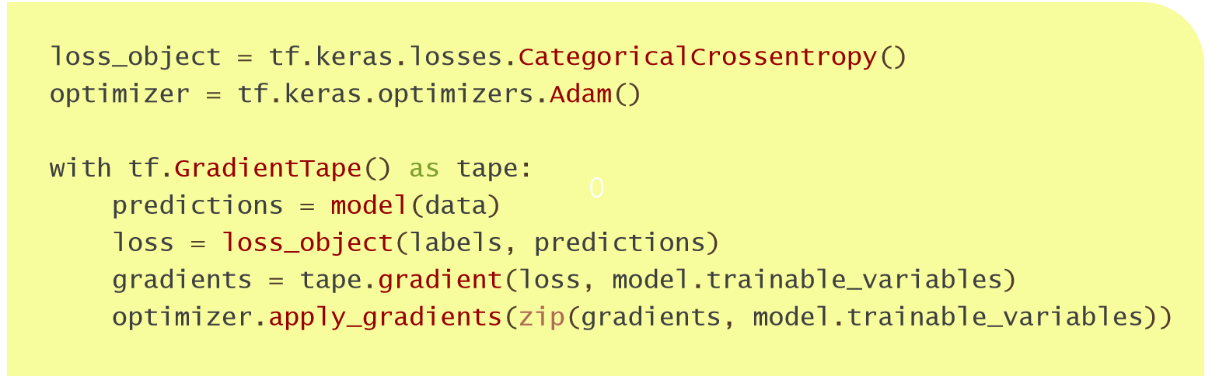

optimizer.apply_gradients(grads_and_vars,name=None)

作用：把计算出来的梯度更新到变量上面去。

参数含义:

- grads_and_vars: (gradient, variable) 对的列表.
- name: 操作名

**使用tf.GradientTape完成lenet模型训练**

In [23]:
# 加载 MNIST 数据集
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()
print('x:', x_train.shape, 'y:', y_train.shape, 'x test:', x_test.shape, 'y test:', y_test)

#构建数据集
train_db = tf.data.Dataset.from_tensor_slices((x_train, y_train)).shuffle(10000).batch(128)
val_db = tf.data.Dataset.from_tensor_slices((x_test[:5000], y_test[:5000])).shuffle(5000).batch(256)
test_db = tf.data.Dataset.from_tensor_slices((x_test[5000:], y_test[5000:])).shuffle(5000).batch(256)


def preprocess(x, y): # 自定义的预处理函数
    # 调用此函数时会自动传入 x,y 对象，shape 为[b, 28, 28], [b]
    # 标准化到 0~1
    x = tf.cast(x, dtype=tf.float32) / 255.-0.5
    x = tf.reshape(x, [-1,28,28,1]) # 增加通道维度
    y = tf.cast(y, dtype=tf.int32) # 转成整形张量 
    y = tf.one_hot(y, depth=10) # one-hot 编码
    # 返回的 x,y 将替换传入的 x,y 参数，从而实现数据的预处理功能
    return x,y

# 预处理函数实现在 preprocess 函数中，传入函数引用即可
train_db = train_db.map(preprocess).cache() 
test_db = test_db.map(preprocess).cache() 
val_db = val_db.map(preprocess).cache() 

#构建模型
lenet = tf.keras.models.Sequential([
    #第一层：6个5*5的卷积核，全0填充；最大池化，2*2的池化核，步长为2，padding='VALID'
    layers.Conv2D(filters=6,kernel_size=5,activation='relu',padding='same'),
    layers.MaxPool2D(pool_size=2,strides=2),
    #第二层
    layers.Conv2D(filters=16,kernel_size=5,activation='relu',padding='same'),
    layers.MaxPool2D(pool_size=2,strides=2),
    #拉直,将(28,28)像素的图像即对应的2维的数组转成一维的数组
    layers.Flatten(),
    #三层全连接网络
    #120个神经元
    layers.Dense(120,activation='relu'),
    layers.Dense(84,activation='relu'),
    layers.Dense(10,activation='softmax')
])

lenet.build(input_shape=(None, 28,28,1))#初始化模型参数

#定义计算准确率的函数
def calc_acc(y_true,y_pred):
    y_true=tf.argmax(y_true,axis=-1)
    y_pred=tf.argmax(y_pred,axis=-1)
    return np.mean(y_true==y_pred)

def train(model,train_data,val_data,epochs=10):
    loss_object = tf.keras.losses.CategoricalCrossentropy()
    optimizer = tf.keras.optimizers.Adam()
    #训练  遍历epochs
    for  epoch in range(1,epochs+1):
        print('-'*10+f"epoch{epoch}"+'-'*10)
        #遍历数据集进行训练
        train_loss=0.
        train_acc=0.
        #遍历数据集进行训练
        for step, (x_batch_train, y_batch_train) in enumerate(train_data):
            # 开一个gradient tape, 计算梯度
            with tf.GradientTape() as tape:
                predictions = model(x_batch_train)#计算输出值
                loss = loss_object(y_batch_train, predictions)#计算损失值
                gradients = tape.gradient(loss, model.trainable_variables)#计算梯度值
            optimizer.apply_gradients(zip(gradients, model.trainable_variables))#优化更新参数
            train_loss+=loss/len(train_data)#累计平均损失
            train_acc+=calc_acc(y_batch_train,predictions)/len(train_data)#累计平均acc
            if step % 200 == 0:
                print('Training loss (for one batch) at step %s: %s' % (step, float(loss)))
                print('Seen so far: %s samples' % ((step + 1) * 128))
                print("")
        print('epoch %s---Training loss : %s---Training acc : %s ' % (epoch, float(train_loss),float(train_acc)))

        #遍历验证机进行验证
        val_loss=0
        val_acc=0
        for x_batch_val, y_batch_val in val_data:#不需要求梯度
            predictions = model(x_batch_val)#计算输出值
            loss = loss_object(y_batch_val, predictions)#计算损失值
            val_loss+=loss/len(val_data)#累计平均损失
            val_acc+=calc_acc(y_batch_val,predictions)/len(val_data)#累计平均acc
        print('epoch %s---val loss : %s---val acc : %s ' % (epoch, float(val_loss),float(val_acc)))
        

train(lenet,train_db,val_db,epochs=10)

x: (60000, 28, 28) y: (60000,) x test: (10000, 28, 28) y test: [7 2 1 ... 4 5 6]
----------epoch1----------
Training loss (for one batch) at step 0: 2.2911524772644043
Seen so far: 128 samples

Training loss (for one batch) at step 200: 0.2259245663881302
Seen so far: 25728 samples

Training loss (for one batch) at step 400: 0.06675557792186737
Seen so far: 51328 samples

epoch 1---Training loss : 0.3325154185295105---Training acc : 0.9041677771854982 
epoch 1---val loss : 0.1726820170879364---val acc : 0.9480813419117646 
----------epoch2----------
Training loss (for one batch) at step 0: 0.2461404800415039
Seen so far: 128 samples

Training loss (for one batch) at step 200: 0.11882763355970383
Seen so far: 25728 samples

Training loss (for one batch) at step 400: 0.01700836420059204
Seen so far: 51328 samples

epoch 2---Training loss : 0.08993101865053177---Training acc : 0.9729366560056836 
epoch 2---val loss : 0.08725305646657944---val acc : 0.9716222426470589 
----------epoch3----

上述代码可以看到tensorflow是训练的时候要指定反向传播过程with tf.GradientTape() as tape:... ，而pytorch中是验证的时候要把自动反向传播关了with torch.no_grad():

### 模型保存和加载
- 保存模型权重

    - 方法一：保存模型权重（model.save_weights）

- 保存整个模型

    - 方法二：保存HDF5文件（model.save）
    - 方法三：保存pb文件（tf.saved_model）

- 保存网络结构

区别：

- saved_model格式的模型可以直接用来预测(predict)，但是saved_model 没有保存优化器配置
- 方法一仅仅保存了模型中的权重(weights)。
- 方法二模型和优化器都可以一起保存，包括权重(weights)、模型配置(architecture)和优化器配置(optimizer configuration)。这样做的好处是，当你恢复模型时，**完全不依赖于原来搭建模型的代码**。
- 保存完整的模型有很多应用场景，比如在浏览器中使用TensorFlow.js 加载运行，比如在移动设备上使用 TensorFlow Lite 加载运行。

**构建一个简单模型并训练**

In [24]:
# 构建一个简单的模型并训练
from __future__ import absolute_import, division, print_function
import tensorflow as tf
tf.keras.backend.clear_session()
from tensorflow import keras
from tensorflow.keras import layers

inputs = layers.Input(shape=(784,), name='digits')
x = layers.Dense(64, activation='relu', name='dense_1')(inputs)
x = layers.Dense(64, activation='relu', name='dense_2')(x)
outputs = layers.Dense(10, activation='softmax', name='predictions')(x)

model = keras.Model(inputs=inputs, outputs=outputs, name='3_layer_mlp')
model.summary()
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
x_train = x_train.reshape(60000, 784).astype('float32') / 255
x_test = x_test.reshape(10000, 784).astype('float32') / 255

model.compile(loss='sparse_categorical_crossentropy',
              optimizer=keras.optimizers.RMSprop())
history = model.fit(x_train, y_train,
                    batch_size=64,
                    epochs=1)

predictions = model.predict(x_test)

Model: "3_layer_mlp"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 digits (InputLayer)         [(None, 784)]             0         
                                                                 
 dense_1 (Dense)             (None, 64)                50240     
                                                                 
 dense_2 (Dense)             (None, 64)                4160      
                                                                 
 predictions (Dense)         (None, 10)                650       
                                                                 
Total params: 55050 (215.04 KB)
Trainable params: 55050 (215.04 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
313/313 [==============================] - 1s 2ms/step


#### 1）仅保存模型权重
- 保存：model.save_weights(path)
- 加载：model.load_weights(path)
- 获取权重：model.get_weights()
- 设置权重：model.set_weights(weights)

保存 = 获取权重 + 写文件  ；  加载 = 读文件 + 设置权重

In [25]:
# 保存权重
model.save_weights('model_storage/ch0601.h5')

In [26]:
# 加载模型权重  加载之前需要先复现网络结构
inputs = layers.Input(shape=(784,), name='digits')
x = layers.Dense(64, activation='relu', name='dense_1')(inputs)
x = layers.Dense(64, activation='relu', name='dense_2')(x)
outputs = layers.Dense(10, activation='softmax', name='predictions')(x)

new_model = keras.Model(inputs=inputs, outputs=outputs, name='3_layer_mlp')
# 加载权重
new_model.load_weights('model_storage/ch0601.h5')
# new_model.get_weights()[0],model.get_weights()[0] #查看权重
new_predictions = new_model.predict(x_test)#加载权重的新模型进行预测
new_predictions[:2],predictions[:2]

313/313 [==============================] - 1s 2ms/step


(array([[2.4710869e-05, 5.8236611e-09, 7.7120977e-04, 1.5405958e-04,
         2.6650363e-07, 8.9155401e-06, 7.1518774e-10, 9.9895477e-01,
         6.4984873e-05, 2.1134672e-05],
        [1.0921215e-03, 2.7456088e-05, 9.8671037e-01, 9.2108613e-03,
         1.4354001e-08, 1.1488837e-03, 1.8290633e-04, 1.0331126e-09,
         1.6274191e-03, 7.7688025e-09]], dtype=float32),
 array([[2.4710869e-05, 5.8236611e-09, 7.7120977e-04, 1.5405958e-04,
         2.6650363e-07, 8.9155401e-06, 7.1518774e-10, 9.9895477e-01,
         6.4984873e-05, 2.1134672e-05],
        [1.0921215e-03, 2.7456088e-05, 9.8671037e-01, 9.2108613e-03,
         1.4354001e-08, 1.1488837e-03, 1.8290633e-04, 1.0331126e-09,
         1.6274191e-03, 7.7688025e-09]], dtype=float32))

#### 2）仅保存网络结构
仅保持网络结构，这样导出的模型并未包含训练好的参数

- 获取网络结构：model.get_config()、model.to_json()
- 加载网络结构：tf.keras.Model.from_config(config)、tf.keras.models.model_from_json(json_config)

In [27]:
# model.get_config()
config = model.get_config() # 获取网络结构
####省略了文件保存和读取的代码####
#保存config
#读取config
reinitialized_model = keras.Model.from_config(config) #加载网络结构构建模型
new_predictions = reinitialized_model.predict(x_test) #使用新构建的模型进行预测  参数是随机初始化的  
new_predictions[:2],predictions[:2]

313/313 [==============================] - 1s 2ms/step


(array([[0.07090962, 0.07416387, 0.08109091, 0.14164491, 0.08178349,
         0.10033709, 0.13705279, 0.1407539 , 0.08080213, 0.09146135],
        [0.07715122, 0.06238337, 0.12935431, 0.09760141, 0.07680091,
         0.08836272, 0.13419202, 0.16628575, 0.08544285, 0.08242536]],
       dtype=float32),
 array([[2.4710869e-05, 5.8236611e-09, 7.7120977e-04, 1.5405958e-04,
         2.6650363e-07, 8.9155401e-06, 7.1518774e-10, 9.9895477e-01,
         6.4984873e-05, 2.1134672e-05],
        [1.0921215e-03, 2.7456088e-05, 9.8671037e-01, 9.2108613e-03,
         1.4354001e-08, 1.1488837e-03, 1.8290633e-04, 1.0331126e-09,
         1.6274191e-03, 7.7688025e-09]], dtype=float32))

In [30]:
json_config = model.to_json()
#保存config
#读取config
reinitialized_model = keras.models.model_from_json(json_config) 
new_predictions = reinitialized_model.predict(x_test)#随机初始化参数
new_predictions[:2],predictions[:2]

313/313 [==============================] - 0s 1ms/step


(array([[0.12492044, 0.10362541, 0.09513324, 0.07504468, 0.07944979,
         0.1284145 , 0.10043986, 0.1336718 , 0.07938524, 0.0799151 ],
        [0.1032709 , 0.12781516, 0.10193591, 0.10238606, 0.0671544 ,
         0.1070492 , 0.09771955, 0.12295852, 0.10165792, 0.06805231]],
       dtype=float32),
 array([[2.4710869e-05, 5.8236611e-09, 7.7120977e-04, 1.5405958e-04,
         2.6650363e-07, 8.9155401e-06, 7.1518774e-10, 9.9895477e-01,
         6.4984873e-05, 2.1134672e-05],
        [1.0921215e-03, 2.7456088e-05, 9.8671037e-01, 9.2108613e-03,
         1.4354001e-08, 1.1488837e-03, 1.8290633e-04, 1.0331126e-09,
         1.6274191e-03, 7.7688025e-09]], dtype=float32))

#### 3）保存全模型
可以对整个模型进行保存，在恢复模型的时候不需要复现网络结构，其保存的内容包括：

- 该模型的架构
- 模型的权重（在训练期间学到的）
- 模型的训练配置（你传递给编译的），如果有的话
- 优化器及其状态（如果有的话）（这使您可以从中断的地方重新启动训练）
- 保存：model.save(path,save_format='tf')
- 加载：tf.keras.models.load_model(path)

##### 方法1 保存为tf模式

In [31]:
model.save('model_storage/ch0602_tf_version', save_format = 'tf') # 网络结构和权重同时保存
new_model = keras.models.load_model('model_storage/ch0602_tf_version') # 网络结构和权重同时加载 不需要复现网络
new_predictions = new_model.predict(x_test)
new_predictions[:2], predictions[:2]

INFO:tensorflow:Assets written to: model_storage/ch0602_tf_version/assets


INFO:tensorflow:Assets written to: model_storage/ch0602_tf_version/assets


313/313 [==============================] - 1s 2ms/step


(array([[2.4710869e-05, 5.8236611e-09, 7.7120977e-04, 1.5405958e-04,
         2.6650363e-07, 8.9155401e-06, 7.1518774e-10, 9.9895477e-01,
         6.4984873e-05, 2.1134672e-05],
        [1.0921215e-03, 2.7456088e-05, 9.8671037e-01, 9.2108613e-03,
         1.4354001e-08, 1.1488837e-03, 1.8290633e-04, 1.0331126e-09,
         1.6274191e-03, 7.7688025e-09]], dtype=float32),
 array([[2.4710869e-05, 5.8236611e-09, 7.7120977e-04, 1.5405958e-04,
         2.6650363e-07, 8.9155401e-06, 7.1518774e-10, 9.9895477e-01,
         6.4984873e-05, 2.1134672e-05],
        [1.0921215e-03, 2.7456088e-05, 9.8671037e-01, 9.2108613e-03,
         1.4354001e-08, 1.1488837e-03, 1.8290633e-04, 1.0331126e-09,
         1.6274191e-03, 7.7688025e-09]], dtype=float32))

##### 方法2 保存为h5文件

In [34]:
model.save('model_storage/ch0602.h5') #网络结构和权重同时保存
new_model = keras.models.load_model('model_storage/ch0602.h5') #网络结构和权重同时加载  不需要复现网络
new_predictions = new_model.predict(x_test)
new_predictions[:2],predictions[:2]

313/313 [==============================] - 1s 2ms/step


(array([[2.4710869e-05, 5.8236611e-09, 7.7120977e-04, 1.5405958e-04,
         2.6650363e-07, 8.9155401e-06, 7.1518774e-10, 9.9895477e-01,
         6.4984873e-05, 2.1134672e-05],
        [1.0921215e-03, 2.7456088e-05, 9.8671037e-01, 9.2108613e-03,
         1.4354001e-08, 1.1488837e-03, 1.8290633e-04, 1.0331126e-09,
         1.6274191e-03, 7.7688025e-09]], dtype=float32),
 array([[2.4710869e-05, 5.8236611e-09, 7.7120977e-04, 1.5405958e-04,
         2.6650363e-07, 8.9155401e-06, 7.1518774e-10, 9.9895477e-01,
         6.4984873e-05, 2.1134672e-05],
        [1.0921215e-03, 2.7456088e-05, 9.8671037e-01, 9.2108613e-03,
         1.4354001e-08, 1.1488837e-03, 1.8290633e-04, 1.0331126e-09,
         1.6274191e-03, 7.7688025e-09]], dtype=float32))

#### 4）保存为pb部署文件
- 保存：tf.saved_model.save(model,path) 、model.save(path,save_format='tf')
- 加载：tf.saved_model.load(path)

**注意：此时加载的模型不同于Keras模型，没有predict等方法，主要方便部署** ***但是一般部署也不用这个***

In [35]:
tf.saved_model.save(model, 'model_storage/ch0603_tf_saved_model_version')

INFO:tensorflow:Assets written to: model_storage/ch0603_tf_saved_model_version/assets


INFO:tensorflow:Assets written to: model_storage/ch0603_tf_saved_model_version/assets


In [36]:
# new_model=tf.saved_model.load('model_storage/ch0602_tf_version')
new_model = tf.saved_model.load('model_storage/ch0603_tf_saved_model_version')
f = new_model.signatures['serving_default'] # 根据读取的模型返回一个推理函数
new_predictions = f(digits = tf.constant(x_test.tolist())) # digits就是网络结构中的输入层的name
new_predictions, predictions[:2]

({'predictions': <tf.Tensor: shape=(10000, 10), dtype=float32, numpy=
  array([[2.4710847e-05, 5.8236500e-09, 7.7121088e-04, ..., 9.9895477e-01,
          6.4984750e-05, 2.1134654e-05],
         [1.0921246e-03, 2.7456195e-05, 9.8671037e-01, ..., 1.0331126e-09,
          1.6274208e-03, 7.7688025e-09],
         [6.5941902e-05, 9.7985363e-01, 3.6148524e-03, ..., 3.3963288e-03,
          8.1398860e-03, 1.8086072e-04],
         ...,
         [2.7389805e-07, 2.6063091e-08, 2.5300465e-06, ..., 8.8802153e-05,
          7.9441228e-04, 8.0884740e-05],
         [2.2623605e-04, 2.5364454e-06, 5.0827509e-07, ..., 3.3806359e-06,
          1.0583694e-02, 2.3615943e-05],
         [6.3455018e-06, 1.3529363e-09, 7.8112993e-07, ..., 1.0378176e-08,
          2.3550825e-07, 2.7745113e-08]], dtype=float32)>},
 array([[2.4710869e-05, 5.8236611e-09, 7.7120977e-04, 1.5405958e-04,
         2.6650363e-07, 8.9155401e-06, 7.1518774e-10, 9.9895477e-01,
         6.4984873e-05, 2.1134672e-05],
        [1.0921215e-03,

#### 5）子类模型参数保存

- Sequential 和 Functional API： 是“静态图”模式。你在一层层搭积木时，Keras 内部构建了一个严密的数据结构图，它完全清楚你有几层、每层叫什么、参数是多少，所以能自动生成详尽的 config 字典。

- Subclassing API： 是“面向对象”的动态模式。self.dense_1 对 Keras 来说，只是一个普通的 Python 类属性；而在 call 方法里写的前向传播逻辑，对 Keras 来说相当于一个黑盒。在没有显式声明的情况下，Keras 无法自动解析出你的网络拓扑结构。

**子类模型的结构无法保存和序列化，只能保持参数，且必须使用tf格式进行保存（不能使用h5格式）**

In [37]:
# 构建模型
class ThreeLayerMLP(keras.Model):
    def __init__(self, name=None):
        super(ThreeLayerMLP, self).__init__(name=name)
        self.dense_1 = layers.Dense(64, activation='relu', name='dense_1')
        self.dense_2 = layers.Dense(64, activation='relu', name='dense_2')
        self.pred_layer = layers.Dense(10, activation='softmax', name='predictions')

    def call(self, inputs):
        x = self.dense_1(inputs)
        x = self.dense_2(x)
        return self.pred_layer(x)
def get_model():
    return ThreeLayerMLP(name='3_layer_mlp')
model = ThreeLayerMLP(name='3_layer_mlp')
# 训练模型
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
x_train = x_train.reshape(60000, 784).astype('float32') / 255
x_test = x_test.reshape(10000, 784).astype('float32') / 255
model.compile(loss='sparse_categorical_crossentropy',
              optimizer=keras.optimizers.RMSprop())
history = model.fit(x_train, y_train,
                    batch_size=64,
                    epochs=1)

938/938 [==============================] - 4s 4ms/step - loss: 0.3258


In [39]:
model.get_config() 
#当前版本不报错，但依然无法保存网络结构，老版本没有重写get_config()就会抛出异常，但是新版本这里会返回通用参数，依然不是一个完整的网络结构

{'name': '3_layer_mlp'}

In [40]:
# 保存模型权重参数
model.save_weights('model_storage/ch0604_my_model_weights', save_format='tf') # 必须保存为tf格式

# 输出结果，供后面对比
predictions = model.predict(x_test)

313/313 [==============================] - 1s 2ms/step


In [41]:
# 读取保存的模型参数
new_model = get_model() # 复现网络结构
new_model.load_weights('model_storage/ch0604_my_model_weights') # 加载参数
new_predictions = new_model.predict(x_test)
new_predictions[:2], predictions[:2]

313/313 [==============================] - 1s 2ms/step


(array([[1.14674098e-04, 9.25845640e-08, 1.47350016e-03, 1.83494389e-03,
         7.50723871e-07, 5.29179670e-06, 5.50321433e-09, 9.96005714e-01,
         2.08449419e-05, 5.44196460e-04],
        [7.11314124e-06, 1.46244774e-05, 9.99694467e-01, 1.01498896e-04,
         1.89818092e-10, 3.50280061e-05, 1.26031155e-04, 3.37219386e-09,
         2.12336490e-05, 1.35993472e-09]], dtype=float32),
 array([[1.14674098e-04, 9.25845640e-08, 1.47350016e-03, 1.83494389e-03,
         7.50723871e-07, 5.29179670e-06, 5.50321433e-09, 9.96005714e-01,
         2.08449419e-05, 5.44196460e-04],
        [7.11314124e-06, 1.46244774e-05, 9.99694467e-01, 1.01498896e-04,
         1.89818092e-10, 3.50280061e-05, 1.26031155e-04, 3.37219386e-09,
         2.12336490e-05, 1.35993472e-09]], dtype=float32))

### 花朵分类实战
#### 1）数据集简介
数据集: flower_photos

- daisy: 633张图片 雏菊
- dandelion: 898张图片 蒲公英
- roses: 641张图片 玫瑰
- sunflowers: 699张图片 向日葵
- tulips: 799张图片 郁金香

flower_photos 数据量比较小，可以使用简单cnn模型，数据集可以选择加载到内存进行训练。

#### 2）构建数据集

In [42]:
import tensorflow as tf
import random
import pathlib
data_path = pathlib.Path('Dataset/flower_photos/')
all_image_paths = list(data_path.glob('*/*'))
all_image_paths = [str(path) for path in all_image_paths] # 所有图片路径的列表
random.shuffle(all_image_paths)
label_names = sorted(item.name for item in data_path.glob('*/') if item.is_dir()) # 加载标签
label_to_index = dict((name, index) for index, name in enumerate(label_names)) # 构建标签字典
all_image_labels = [label_to_index[pathlib.Path(path).parent.name] for path in all_image_paths] # 标签id化

# 分割数据集
total_num = len(all_image_paths)
split_index = int(0.8*total_num)
train_x, train_y = all_image_paths[:split_index], all_image_labels[:split_index]
val_x, val_y = all_image_paths[split_index:], all_image_labels[split_index:]

# 构建数据集
train_db = tf.data.Dataset.from_tensor_slices((train_x, train_y))
val_db = tf.data.Dataset.from_tensor_slices((val_x, val_y))

# 定义预处理方法
def load_and_preprocess_from_path_label(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [150, 150])  # 原始图片大小为(266, 320, 3)，重设为(192, 192)
    image /= 255.0  # 归一化到[0,1]范围
    return image, label
train_db  = train_db.map(load_and_preprocess_from_path_label)
val_db  = val_db.map(load_and_preprocess_from_path_label)

#打乱并分批次
BATCH_SIZE = 32
train_db = train_db.shuffle(1000).batch(BATCH_SIZE).cache().prefetch(1000)
val_db = val_db.batch(BATCH_SIZE).cache().prefetch(1000)

In [43]:
tx, ty = next(iter(train_db))
ty

2026-04-06 18:21:35.463497: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 8640128000 bytes after encountering the first element of size 8640128 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
2026-04-06 18:21:35.467100: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


<tf.Tensor: shape=(32,), dtype=int32, numpy=
array([4, 1, 4, 0, 1, 3, 2, 1, 4, 4, 1, 3, 2, 3, 1, 1, 1, 0, 2, 4, 1, 4,
       4, 0, 3, 4, 0, 3, 1, 2, 3, 2], dtype=int32)>

#### 3）搭建模型

搭建一个拥有3层卷积和2层全连接的模型

In [44]:
num_classes=len(label_names)
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(num_classes)
])
model.build(input_shape = (None, 150, 150, 3)) # 初始化模型参数
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 148, 148, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 74, 74, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 72, 72, 32)        9248      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 36, 36, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 34, 34, 32)        9248      
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 17, 17, 32)        0

#### 4）模型训练

分别使用两种方式进行训练

##### 1.keras方式

In [45]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
model.compile(
    optimizer = optimizer,
    loss = tf.losses.SparseCategoricalCrossentropy(from_logits = True),
    metrics = ['accuracy']
)
model.fit(train_db, epochs = 10, validation_data = val_db)

Epoch 1/10


2026-04-06 18:25:30.936745: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 8640128000 bytes after encountering the first element of size 8640128 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


92/92 [==============================] - ETA: 0s - loss: 1.3723 - accuracy: 0.4196

2026-04-06 18:25:35.657280: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 8640256000 bytes after encountering the first element of size 8640256 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


92/92 [==============================] - 7s 34ms/step - loss: 1.3723 - accuracy: 0.4196 - val_loss: 1.2067 - val_accuracy: 0.4946
Epoch 2/10
13/92 [===>..........................] - ETA: 1s - loss: 1.1591 - accuracy: 0.4928

...

2026-04-06 18:25:47.225884: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 8640256000 bytes after encountering the first element of size 8640256 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
2026-04-06 18:25:47.368359: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 8640128000 bytes after encountering the first element of size 8640128 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


92/92 [==============================] - 2s 17ms/step - loss: 0.6881 - accuracy: 0.7520 - val_loss: 1.0012 - val_accuracy: 0.6172
Epoch 10/10
 5/92 [>.............................] - ETA: 1s - loss: 0.7255 - accuracy: 0.7250

2026-04-06 18:25:48.767604: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 8640256000 bytes after encountering the first element of size 8640256 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
2026-04-06 18:25:48.894544: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 8640128000 bytes after encountering the first element of size 8640128 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


92/92 [==============================] - 2s 17ms/step - loss: 0.6474 - accuracy: 0.7732 - val_loss: 1.0145 - val_accuracy: 0.6144


2026-04-06 18:25:50.356610: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 8640256000 bytes after encountering the first element of size 8640256 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


##### 2.GradientTape

In [48]:
import numpy as np

# 定义计算准确率的函数
def calc_acc(y_true, y_pred):
    y_pred = tf.cast(tf.argmax(y_pred, axis = -1), tf.int32)
    return np.mean(y_true == y_pred)

def train(model, train_data, val_data, epochs = 10):
    loss_object = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
    epochs = 10
    # 训练 遍历epochs
    for epoch in range(1, epochs + 1):
        print('-'*10+f"epoch{epoch}"+'-'*10)
        #遍历数据集进行训练
        train_loss=0
        train_acc=0
        for step, (x_batch_train, y_batch_train) in enumerate(train_data):
            # 开一个gradient tape，计算梯度
            with tf.GradientTape() as tape:
                predictions = model(x_batch_train) # 计算输出值
                loss = loss_object(y_batch_train, predictions) # 计算损失值
                gradients = tape.gradient(loss, model.trainable_variables) # 计算梯度值
                optimizer.apply_gradients(zip(gradients, model.trainable_variables)) # 优化更新参数
                train_loss += loss / len(train_data) # 累计平均损失
                train_acc += calc_acc(y_batch_train, predictions) / len(train_data) # 累计平均acc
            if step % 30 == 0:
                print('Training loss (for one batch) at step %s: %s' % (step, float(loss)))
                print('Seen so far: %s samples' % ((step + 1) * 32))
                print("")
        print('epoch %s---Training loss : %s---Training acc : %s ' % (epoch, float(train_loss),float(train_acc)))

        # 遍历验证集进行验证
        val_loss=0
        val_acc=0
        for x_batch_val, y_batch_val in val_data:#不需要求梯度
            predictions = model(x_batch_val)#计算输出值
            loss = loss_object(y_batch_val, predictions)#计算损失值
            val_loss+=loss/len(val_data)#累计平均损失
            val_acc+=calc_acc(y_batch_val,predictions)/len(val_data)#累计平均acc
        print('epoch %s---val loss : %s---val acc : %s ' % (epoch, float(val_loss),float(val_acc)))

train(model, train_db, val_db, epochs=10)

----------epoch1----------


2026-04-06 18:37:54.515755: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 8640128000 bytes after encountering the first element of size 8640128 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


Training loss (for one batch) at step 0: 0.5628068447113037
Seen so far: 32 samples

Training loss (for one batch) at step 30: 0.6058489084243774
Seen so far: 992 samples

Training loss (for one batch) at step 60: 0.943946123123169
Seen so far: 1952 samples

Training loss (for one batch) at step 90: 0.4899536371231079
Seen so far: 2912 samples

epoch 1---Training loss : 0.6177668571472168---Training acc : 0.7881567028985509 


2026-04-06 18:38:01.255132: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 8640256000 bytes after encountering the first element of size 8640256 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


epoch 1---val loss : 1.002690076828003---val acc : 0.622554347826087 
----------epoch2----------
Training loss (for one batch) at step 0: 0.46412286162376404
Seen so far: 32 samples



...

epoch 9---val loss : 1.1518498659133911---val acc : 0.6144927536231882 
----------epoch10----------
Training loss (for one batch) at step 0: 0.30493447184562683
Seen so far: 32 samples



2026-04-06 18:38:31.377635: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 8640128000 bytes after encountering the first element of size 8640128 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


Training loss (for one batch) at step 30: 0.3982027471065521
Seen so far: 992 samples

Training loss (for one batch) at step 60: 0.5460054874420166
Seen so far: 1952 samples

Training loss (for one batch) at step 90: 0.3294709026813507
Seen so far: 2912 samples

epoch 10---Training loss : 0.3439323604106903---Training acc : 0.9003623188405795 


2026-04-06 18:38:34.946511: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 8640256000 bytes after encountering the first element of size 8640256 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


epoch 10---val loss : 1.1734737157821655---val acc : 0.6144927536231883 
